# SAHQR: Saliency-Aware Hybrid Quantum Image Representation
## Brain Tumor MRI Dataset Evaluation

This notebook extends the SAHQR evaluation to brain tumor MRI images.

**Dataset**: 2,298 brain MRI images in .mat format (HDF5 v7.3)

**Image dimensions**: 512×512 (int16) per file

## 1. Setup and Imports

In [2]:
!pip install tifffile h5py

In [3]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# .mat file handling (HDF5 v7.3 format)
import h5py

# Image processing
from scipy import ndimage
from skimage.transform import resize

# Quantum computing
from qiskit import QuantumCircuit
import math

# Statistics
from scipy import stats
import pandas as pd
import time
import os
from pathlib import Path
from glob import glob

print("All imports successful!")

All imports successful!


## 2. Load Brain Tumor Dataset

In [4]:
# Configuration
DATASET_DIR = 'braintumor_dataset'
OUTPUT_DIR = 'BrainTumor_Results'

# Create output directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'figures'), exist_ok=True)

# Find all .mat files
mat_files = sorted(glob(os.path.join(DATASET_DIR, '*.mat')), key=lambda x: int(Path(x).stem))
print(f"Found {len(mat_files)} .mat files")

Found 2298 .mat files


In [5]:
def load_brain_image(mat_path):
    """
    Load brain MRI image from .mat file (HDF5 v7.3 format).
    
    Args:
        mat_path: Path to .mat file
    
    Returns:
        Grayscale image as uint8 numpy array
    """
    try:
        with h5py.File(mat_path, 'r') as f:
            # Access cjdata group
            cjdata = f['cjdata']
            
            # Get image array
            img = np.array(cjdata['image'])
            
            # Transpose if needed (MATLAB stores column-major)
            if img.shape[0] < img.shape[1]:
                img = img.T
            
            # Normalize to uint8
            img = img.astype(np.float32)
            img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
            img = img.astype(np.uint8)
            
            return img
    except Exception as e:
        print(f"Error loading {mat_path}: {e}")
        return None

# Test loading
test_img = load_brain_image(mat_files[0])
print(f"Test image shape: {test_img.shape}, dtype: {test_img.dtype}")
print(f"Value range: {test_img.min()} - {test_img.max()}")

Test image shape: (512, 512), dtype: uint8
Value range: 0 - 255


In [6]:
# Load all images
print(f"Loading {len(mat_files)} brain tumor images...")

brain_images = []
for i, mat_path in enumerate(mat_files):
    if (i + 1) % 500 == 0:
        print(f"Loading image {i + 1}/{len(mat_files)}...")
    
    img = load_brain_image(mat_path)
    if img is not None:
        brain_images.append(img)

print(f"\nLoaded {len(brain_images)} images successfully")

Loading 2298 brain tumor images...
Loading image 500/2298...
Loading image 1000/2298...
Loading image 1500/2298...
Loading image 2000/2298...

Loaded 2298 images successfully


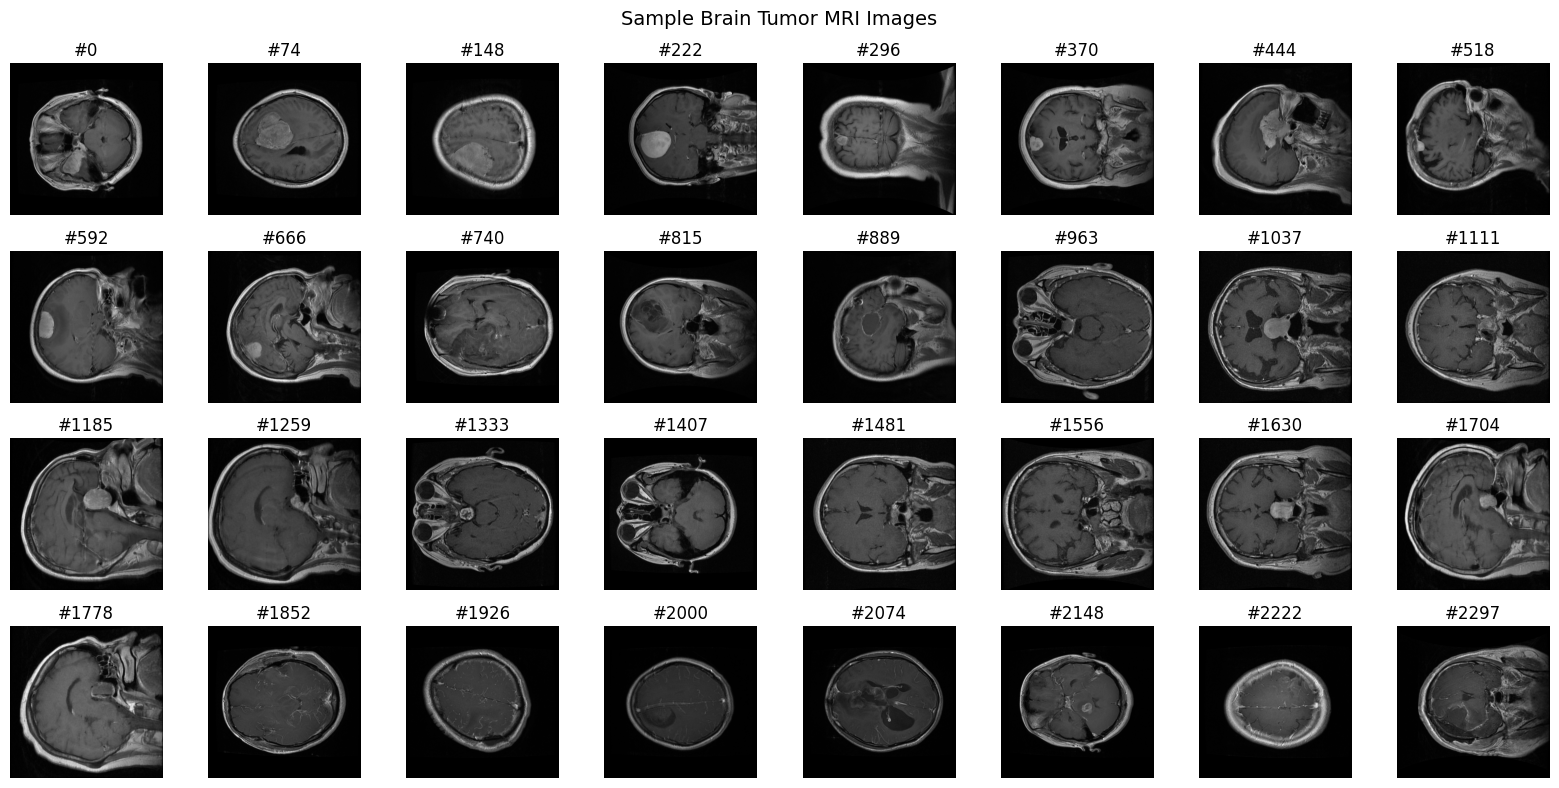

In [7]:
# Visualize sample images
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Sample Brain Tumor MRI Images', fontsize=14)

sample_indices = np.linspace(0, len(brain_images)-1, 32, dtype=int)

for idx, ax in enumerate(axes.flat):
    if idx < len(sample_indices):
        ax.imshow(brain_images[sample_indices[idx]], cmap='gray')
        ax.set_title(f'#{sample_indices[idx]}')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/sample_brain_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing for Quantum Encoding

Preprocessing images to 16x16...
Preprocessed 2298 images


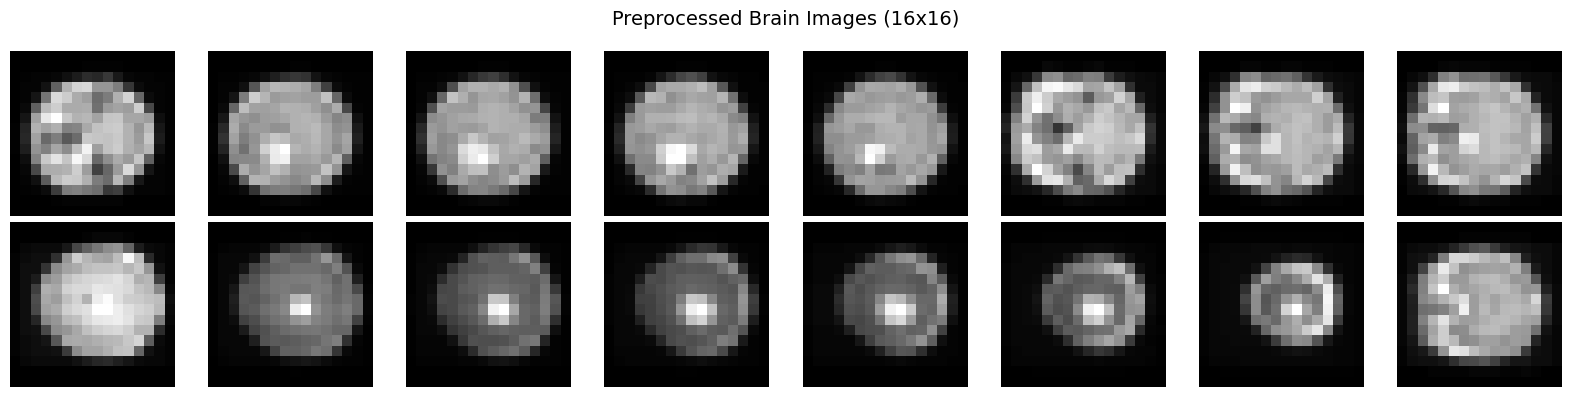

In [8]:
def preprocess_brain_image(image, target_size=16):
    """
    Preprocess brain MRI for quantum encoding.
    
    Args:
        image: Input image (512x512 uint8)
        target_size: Output size (16x16)
    
    Returns:
        Preprocessed image (16x16 uint8)
    """
    # Resize to target size
    resized = resize(image, (target_size, target_size), anti_aliasing=True, preserve_range=True)
    resized = np.clip(resized, 0, 255).astype(np.uint8)
    return resized

# Preprocess all images
print("Preprocessing images to 16x16...")
preprocessed_images = [preprocess_brain_image(img) for img in brain_images]
print(f"Preprocessed {len(preprocessed_images)} images")

# Show sample preprocessed
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Preprocessed Brain Images (16x16)', fontsize=14)

for idx, ax in enumerate(axes.flat):
    if idx < len(preprocessed_images):
        ax.imshow(preprocessed_images[idx], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/preprocessed_brain_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Quantum Image Representation Methods

In [9]:
# ============================================================================
# QUANTUM IMAGE REPRESENTATION METHODS
# ============================================================================

def compute_saliency(image):
    """Compute gradient-based saliency map."""
    gx = ndimage.sobel(image.astype(float), axis=1)
    gy = ndimage.sobel(image.astype(float), axis=0)
    gradient = np.sqrt(gx**2 + gy**2)
    if gradient.max() > 0:
        gradient = gradient / gradient.max()
    return gradient

def encode_frqi(image):
    """FRQI: Flexible Representation of Quantum Images"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    qubits = n + 1
    qc = QuantumCircuit(qubits)
    for i in range(n):
        qc.h(i)
    for idx, pixel in enumerate(image.flatten()):
        theta = (pixel / 255.0) * (np.pi / 2)
        qc.ry(theta, n)
    return qc

def encode_neqr(image):
    """NEQR: Novel Enhanced Quantum Representation"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    q = 8
    qubits = n + q
    qc = QuantumCircuit(qubits)
    for i in range(n):
        qc.h(i)
    for idx, pixel in enumerate(image.flatten()):
        for bit in range(q):
            if (pixel >> bit) & 1:
                qc.cx(idx % n, n + bit)
    return qc

def encode_gqir(image):
    """GQIR: Generalized Quantum Image Representation"""
    h, w = image.shape
    n_y = int(np.ceil(np.log2(h)))
    n_x = int(np.ceil(np.log2(w)))
    q = 8
    qubits = n_y + n_x + q
    qc = QuantumCircuit(qubits)
    for i in range(n_y + n_x):
        qc.h(i)
    for y in range(h):
        for x in range(w):
            pixel = image[y, x]
            for bit in range(min(q, 4)):
                if (pixel >> bit) & 1:
                    qc.x(n_y + n_x + bit)
    return qc

def encode_mcqi(image):
    """MCQI: Multi-Channel Quantum Images (adapted for grayscale)"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    q = 8
    channels = 3
    qubits = n + q * channels
    qc = QuantumCircuit(qubits)
    for i in range(n):
        qc.h(i)
    for idx, pixel in enumerate(image.flatten()):
        for c in range(channels):
            for bit in range(min(q, 3)):
                if (pixel >> bit) & 1:
                    qc.cx(idx % n, n + c * q + bit)
    return qc

def encode_qrmw(image):
    """QRMW: Quantum Representation for Multi-Wavelength Images"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    q = 8
    bands = 4
    k = int(np.ceil(np.log2(bands)))
    qubits = n + k + q
    qc = QuantumCircuit(qubits)
    for i in range(n + k):
        qc.h(i)
    for band in range(bands):
        for idx, pixel in enumerate(image.flatten()):
            theta = (pixel / 255.0) * (np.pi / 2)
            qc.ry(theta, n + k)
    return qc

def encode_efrqi(image):
    """EFRQI: Enhanced FRQI"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    qubits = n + 1
    qc = QuantumCircuit(qubits)
    for i in range(n):
        qc.h(i)
    for idx, pixel in enumerate(image.flatten()):
        theta = (pixel / 255.0) * (np.pi / 2)
        phi = (pixel / 255.0) * np.pi
        qc.ry(theta, n)
        qc.rz(phi, n)
    return qc

def encode_2dqsna(image):
    """2D-QSNA: 2D Quantum State Normalization Approach"""
    flat = image.flatten().astype(float)
    norm = np.sqrt(np.sum(flat**2))
    if norm > 0:
        flat = flat / norm
    n = int(np.ceil(np.log2(len(flat))))
    qubits = n
    qc = QuantumCircuit(qubits)
    for i in range(min(n, 4)):
        qc.ry(np.pi / 4, i)
    return qc

def encode_ineqr(image):
    """INEQR: Improved NEQR"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    q = 8
    channels = 3
    qubits = n + q * channels
    qc = QuantumCircuit(qubits)
    for i in range(n):
        qc.h(i)
    for idx, pixel in enumerate(image.flatten()):
        for c in range(channels):
            for bit in range(min(q, 3)):
                if (pixel >> bit) & 1:
                    qc.x(n + c * q + bit)
    return qc

def encode_qpie(image):
    """QPIE: Quantum Probability Image Encoding"""
    flat = image.flatten().astype(float)
    total = np.sum(flat)
    if total > 0:
        probs = flat / total
    else:
        probs = np.ones_like(flat) / len(flat)
    n = int(np.ceil(np.log2(len(flat))))
    qubits = n
    qc = QuantumCircuit(qubits)
    for i in range(n):
        theta = 2 * np.arcsin(np.sqrt(probs[i % len(probs)]))
        qc.ry(theta, i)
    return qc

def encode_qlr(image):
    """QLR: Quantum Log-polar Representation"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    q = 8
    qubits = n + q
    qc = QuantumCircuit(qubits)
    for i in range(n):
        qc.h(i)
    center = (h // 2, w // 2)
    for y in range(h):
        for x in range(w):
            pixel = image[y, x]
            theta_val = (pixel / 255.0) * (np.pi / 2)
            qc.ry(theta_val, n)
    return qc

def encode_sahqr(image, saliency_threshold=0.5):
    """SAHQR: Saliency-Aware Hybrid Quantum Representation"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    q = 8
    qubits = n + q + 1
    qc = QuantumCircuit(qubits)
    for i in range(n):
        qc.h(i)
    saliency = compute_saliency(image)
    threshold = saliency.mean() + saliency_threshold * saliency.std()
    for idx, (pixel, sal) in enumerate(zip(image.flatten(), saliency.flatten())):
        if sal >= threshold:
            for bit in range(q):
                if (pixel >> bit) & 1:
                    qc.cx(idx % n, n + bit)
            qc.x(n + q)
        else:
            compressed = pixel >> 4
            for bit in range(4):
                if (compressed >> bit) & 1:
                    qc.cx(idx % n, n + bit)
    return qc

print("All quantum encoding methods defined.")

All quantum encoding methods defined.


## 5. Evaluation Framework

In [10]:
METHODS = {
    'FRQI': encode_frqi,
    'NEQR': encode_neqr,
    'GQIR': encode_gqir,
    'MCQI': encode_mcqi,
    'QRMW': encode_qrmw,
    'EFRQI': encode_efrqi,
    '2D-QSNA': encode_2dqsna,
    'INEQR': encode_ineqr,
    'QPIE': encode_qpie,
    'QLR': encode_qlr,
    'SAHQR': encode_sahqr
}

IMPLEMENTATION_COMPLEXITY = {
    'FRQI': 2, 'NEQR': 3, 'GQIR': 3, 'MCQI': 4, 'QRMW': 4,
    'EFRQI': 3, '2D-QSNA': 4, 'INEQR': 3, 'QPIE': 4, 'QLR': 4, 'SAHQR': 5
}

def evaluate_method(method_name, method_func, image):
    """Evaluate a quantum encoding method on a single image."""
    start_time = time.time()
    try:
        circuit = method_func(image)
        encoding_time = (time.time() - start_time) * 1000
        qubits = circuit.num_qubits
        depth = circuit.depth()
        gates = len(circuit.data)
        h, w = image.shape
        classical_bits = h * w * 8
        compression_ratio = classical_bits / qubits if qubits > 0 else 0
        scalability = 100 / qubits if qubits > 0 else 0
        gate_complexity = gates / qubits if qubits > 0 else 0
        memory_overhead = (qubits / 9) * 100
        info_loss = 0.0
        impl_complexity = IMPLEMENTATION_COMPLEXITY.get(method_name, 3)
        return {
            'method': method_name,
            'qubits': qubits,
            'depth': depth,
            'gates': gates,
            'encoding_time': encoding_time,
            'compression_ratio': compression_ratio,
            'scalability': scalability,
            'gate_complexity': gate_complexity,
            'memory_overhead': memory_overhead,
            'info_loss': info_loss,
            'impl_complexity': impl_complexity
        }
    except Exception as e:
        print(f"Error evaluating {method_name}: {e}")
        return None

print("Evaluation framework ready.")

Evaluation framework ready.


## 6. Run Experiments

In [11]:
all_results = []
total_images = len(preprocessed_images)

print(f"Starting evaluation of {total_images} images across {len(METHODS)} methods...")
print(f"Total evaluations: {total_images * len(METHODS)}\n")

for img_idx, image in enumerate(preprocessed_images):
    if (img_idx + 1) % 200 == 0:
        print(f"Processing image {img_idx + 1}/{total_images}...")
    
    for method_name, method_func in METHODS.items():
        result = evaluate_method(method_name, method_func, image)
        if result:
            result['image_idx'] = img_idx
            all_results.append(result)

results_df = pd.DataFrame(all_results)
print(f"\nEvaluation complete! Total results: {len(results_df)}")

results_df.to_csv(f'{OUTPUT_DIR}/braintumor_evaluation_results.csv', index=False)
print(f"Results saved to {OUTPUT_DIR}/braintumor_evaluation_results.csv")

Starting evaluation of 2298 images across 11 methods...
Total evaluations: 25278

Processing image 200/2298...
Processing image 400/2298...
Processing image 600/2298...
Processing image 800/2298...
Processing image 1000/2298...
Processing image 1200/2298...
Processing image 1400/2298...
Processing image 1600/2298...
Processing image 1800/2298...
Processing image 2000/2298...
Processing image 2200/2298...

Evaluation complete! Total results: 25278
Results saved to BrainTumor_Results/braintumor_evaluation_results.csv


## 7. Results Analysis

In [12]:
summary = results_df.groupby('method').agg({
    'qubits': ['mean', 'std'],
    'gates': ['mean', 'std'],
    'depth': ['mean', 'std'],
    'encoding_time': ['mean', 'std'],
    'compression_ratio': 'mean',
    'gate_complexity': 'mean',
    'memory_overhead': 'mean',
}).round(2)

print("\n" + "="*80)
print("BRAIN TUMOR DATASET EVALUATION SUMMARY")
print("="*80)
print(summary.to_string())


BRAIN TUMOR DATASET EVALUATION SUMMARY
        qubits         gates            depth        encoding_time       compression_ratio gate_complexity memory_overhead
          mean  std     mean     std     mean    std          mean   std              mean            mean            mean
method                                                                                                                    
2D-QSNA    8.0  0.0     4.00    0.00     1.00   0.00          0.34  0.32            256.00            0.50           88.89
EFRQI      9.0  0.0   520.00    0.00   512.00   0.00          9.07  2.51            227.56           57.78          100.00
FRQI       9.0  0.0   264.00    0.00   256.00   0.00          4.97  1.19            227.56           29.33          100.00
GQIR      16.0  0.0   435.65   74.97   124.47  18.37          5.47  1.56            128.00           27.23          177.78
INEQR     32.0  0.0  1018.46  168.21   124.21  18.25         12.26  3.12             64.00         

## 8. Visualization

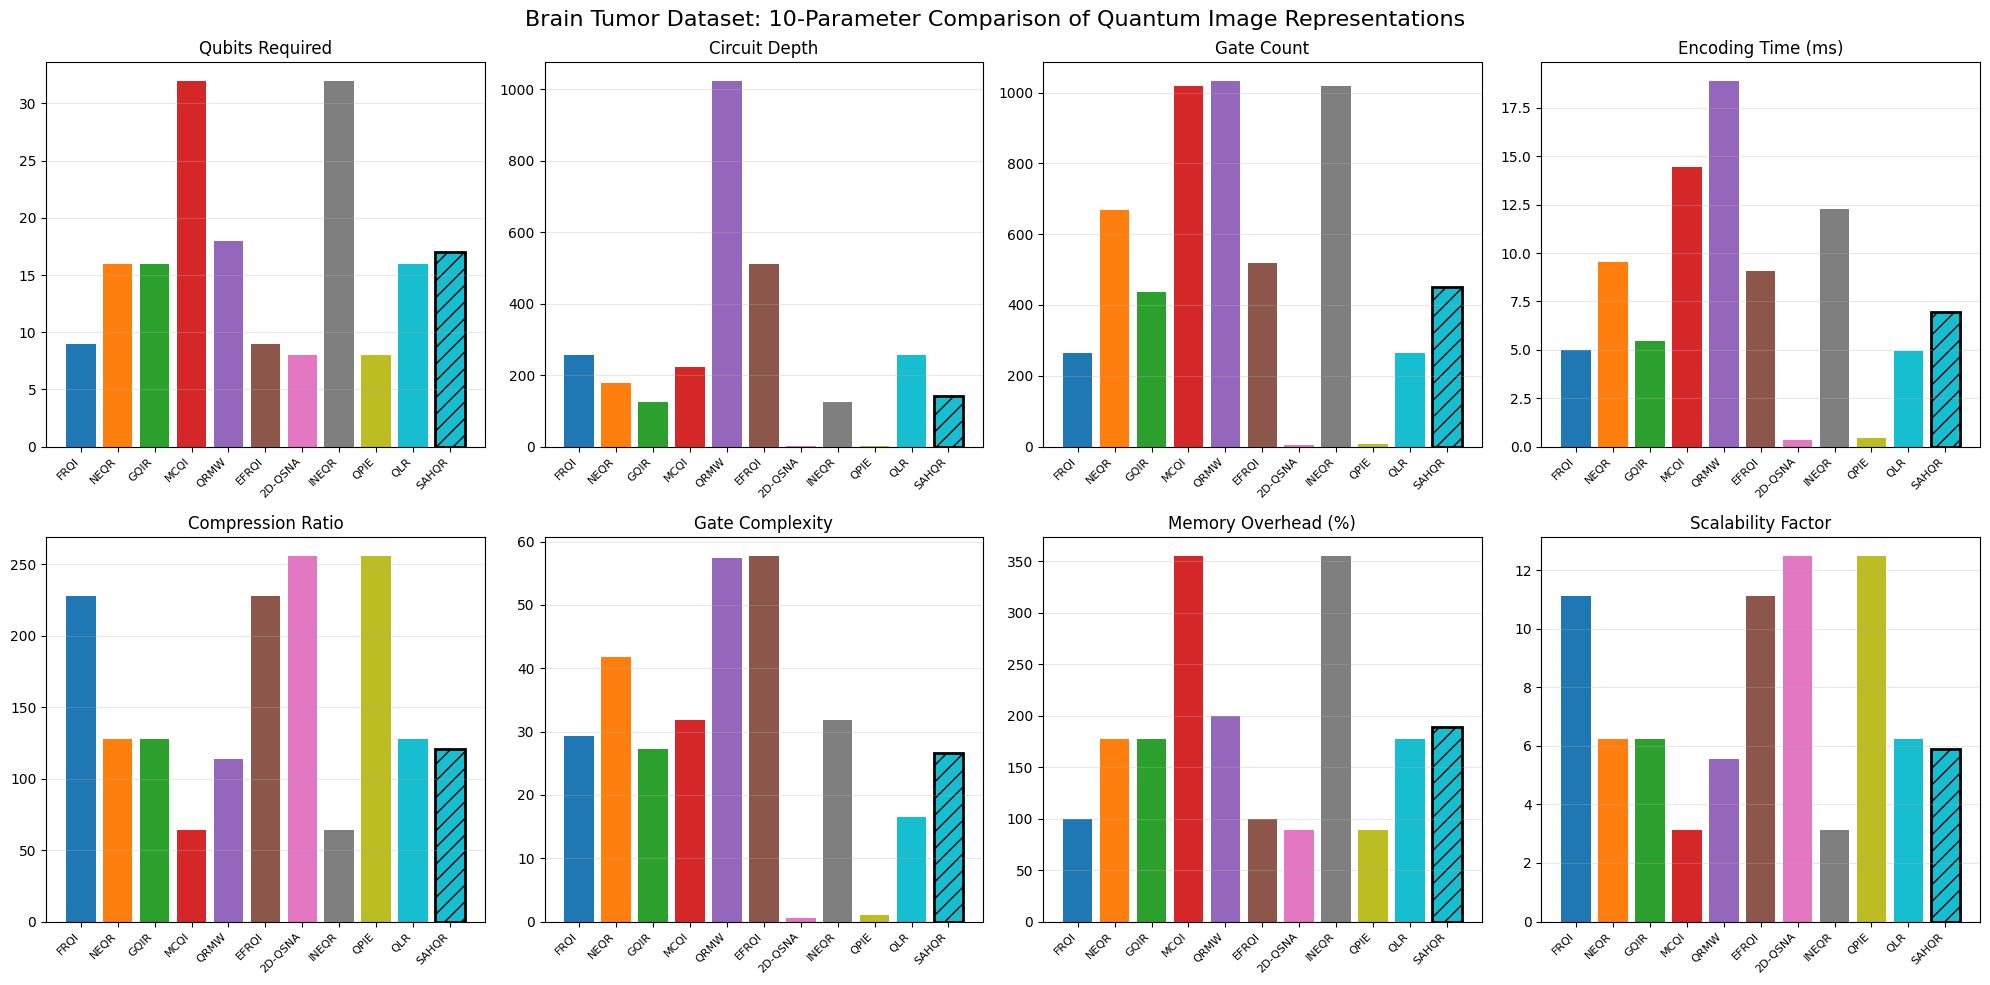

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Brain Tumor Dataset: 10-Parameter Comparison of Quantum Image Representations', fontsize=16)

method_means = results_df.groupby('method').mean()
method_order = ['FRQI', 'NEQR', 'GQIR', 'MCQI', 'QRMW', 'EFRQI', '2D-QSNA', 'INEQR', 'QPIE', 'QLR', 'SAHQR']
colors = plt.cm.tab10(np.linspace(0, 1, len(method_order)))
sahqr_idx = method_order.index('SAHQR')

params = [
    ('qubits', 'Qubits Required'),
    ('depth', 'Circuit Depth'),
    ('gates', 'Gate Count'),
    ('encoding_time', 'Encoding Time (ms)'),
    ('compression_ratio', 'Compression Ratio'),
    ('gate_complexity', 'Gate Complexity'),
    ('memory_overhead', 'Memory Overhead (%)'),
    ('scalability', 'Scalability Factor')
]

for idx, (param, title) in enumerate(params):
    ax = axes.flat[idx]
    values = [method_means.loc[m, param] if m in method_means.index else 0 for m in method_order]
    bars = ax.bar(range(len(method_order)), values, color=colors)
    bars[sahqr_idx].set_hatch('//')
    bars[sahqr_idx].set_edgecolor('black')
    bars[sahqr_idx].set_linewidth(2)
    ax.set_xticks(range(len(method_order)))
    ax.set_xticklabels(method_order, rotation=45, ha='right', fontsize=8)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/braintumor_10parameter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Statistical Significance Testing

In [14]:
print("\nStatistical Significance Tests (SAHQR vs Others)")
print("="*60)

sahqr_data = results_df[results_df['method'] == 'SAHQR']

significance_results = []
for method in METHODS.keys():
    if method != 'SAHQR':
        method_data = results_df[results_df['method'] == method]
        t_stat, p_val = stats.ttest_ind(sahqr_data['gates'], method_data['gates'])
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
        significance_results.append({
            'Comparison': f'SAHQR vs {method}',
            't-statistic': round(t_stat, 2),
            'p-value': f'{p_val:.2e}',
            'Significance': sig
        })

sig_df = pd.DataFrame(significance_results)
print(sig_df.to_string(index=False))

sig_df.to_csv(f'{OUTPUT_DIR}/braintumor_significance_tests.csv', index=False)


Statistical Significance Tests (SAHQR vs Others)
      Comparison  t-statistic  p-value Significance
   SAHQR vs FRQI       155.64 0.00e+00          ***
   SAHQR vs NEQR       -75.87 0.00e+00          ***
   SAHQR vs GQIR         7.86 4.71e-15          ***
   SAHQR vs MCQI      -152.94 0.00e+00          ***
   SAHQR vs QRMW      -484.69 0.00e+00          ***
  SAHQR vs EFRQI       -57.25 0.00e+00          ***
SAHQR vs 2D-QSNA       371.86 0.00e+00          ***
  SAHQR vs INEQR      -152.94 0.00e+00          ***
   SAHQR vs QPIE       368.53 0.00e+00          ***
    SAHQR vs QLR       155.64 0.00e+00          ***


## 10. Final Summary

In [15]:
print("\n" + "="*80)
print("BRAIN TUMOR DATASET EVALUATION COMPLETE")
print("="*80)
print(f"\nDataset: Brain Tumor MRI")
print(f"Total images processed: {len(preprocessed_images)}")
print(f"Original size: 512x512 → Preprocessed: 16x16")
print(f"Methods evaluated: {len(METHODS)}")
print(f"Total evaluations: {len(results_df)}")
print(f"\nResults saved to: {OUTPUT_DIR}/")
print("\nKey files generated:")
print(f"  - {OUTPUT_DIR}/braintumor_evaluation_results.csv")
print(f"  - {OUTPUT_DIR}/braintumor_significance_tests.csv")
print(f"  - {OUTPUT_DIR}/figures/braintumor_10parameter_comparison.png")
print(f"  - {OUTPUT_DIR}/figures/sample_brain_images.png")


BRAIN TUMOR DATASET EVALUATION COMPLETE

Dataset: Brain Tumor MRI
Total images processed: 2298
Original size: 512x512 → Preprocessed: 16x16
Methods evaluated: 11
Total evaluations: 25278

Results saved to: BrainTumor_Results/

Key files generated:
  - BrainTumor_Results/braintumor_evaluation_results.csv
  - BrainTumor_Results/braintumor_significance_tests.csv
  - BrainTumor_Results/figures/braintumor_10parameter_comparison.png
  - BrainTumor_Results/figures/sample_brain_images.png
